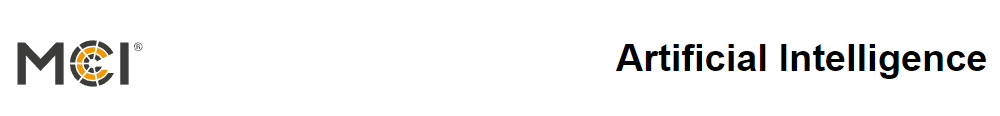

---

# 01 b YOLO Pose Estimation applied to football

First: Import all needed packages

https://docs.ultralytics.com/quickstart/#install-ultralytics

https://docs.ultralytics.com/quickstart/#use-ultralytics-with-python

In [6]:
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2 as cv
from PIL import Image
from matplotlib import pyplot as plt
from scipy import signal

## 1. Keypoint Extraction

The next task we want to perform is a *Keypoint Extraction*. Therefore we need to define
 * the path to source picture
 * the YOLO model we want to use

In [8]:
# Path to the source video
videopath = '../Data/Test_Videos/Football_Performance_Metric.avi'

# Load custom trained YOLOv26 model
# different models n, s, m, l, x
model_pose = YOLO('yolo26n-pose.pt')    # Pose Estimation

Now we can apply this model to our source image

In [9]:
results_det = model_pose(source=videopath, save=True)


WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/209) c:\Codespace\Advanced-Data-Analysis-and-AI-Course-MCI\Pose_Estimation\..\Data\Test_Videos\Football_Performance_Metric.avi: 512x640 1 person, 38.2ms
video 1/1 (frame 2/209) c:\Codespace\Advanced-Data-Analysis-and-AI-Course-MCI\Pose_Estimation\..\Data\Test_Videos\Football_Performance_Metric.avi: 512x640 1 person, 24.3ms
video 1/1 (frame 3/209) c:\Codespace\Advanced-Data-Analysis-and-AI-Course-MCI\Pose_Estimation\..\Data\Test_Videos\Foo

The resulting video shows how a football player is tracked and the pose is accurately identified in each frame. This could be of use for the downstream task of performacne evaluation in fooball. 

# 2. Keypoints over Time

Since we now know, that we can extract the keyjoints from a video, we can look at it as some sort of feature extraction. The keyjoints over time can give us some insight about the movements and patterns within it. Therefore, We need to adress the Keypoints as signals. Let's have a closer look at them.

In [10]:
def yolo_Keypoints_Extended(video_path):
    # Load YOLO model with tracking enabled
    model = YOLO('yolo26n-pose.pt')  # Load the yolo pose model
    
    cap = cv.VideoCapture(video_path)
    no_Frames = int(cap.get(cv.CAP_PROP_FRAME_COUNT))
    print('Total number of frames is', no_Frames)
    
    list_of_poses = []  # List to store tracked objects
    frame_count = 0
    
    while True:
        ret, frame = cap.read()
        if not ret:
            print('No frames grabbed!')
            break
        
        frame_count += 1
        
        # Process frame with Yolo Pose
        results = model_pose(frame)
        
        if results[0].boxes is not None:
                for r in results:
                    boxes = r.boxes  # Boxes object for bbox outputs
                    masks = r.masks  # Masks object for segment masks outputs
                    probs = r.probs  # Class probabilities for classification outputs
                    keypoints = r.keypoints # Keypoints object for pose estimation outputs
                
                list_of_poses.append({
                    'frame': frame_count,
                    'masks': masks,
                    'boxes': boxes,
                    'probs': probs,
                    'keypoints': keypoints
                })
        
        # Optional: Display the frame (comment out if not needed)
        #frame_ = results[0].plot()
        #cv.imshow('Result YOLO frame', frame_)
        
        k = cv.waitKey(30) & 0xff
        if k == 27:
            break
    
    cap.release()
    cv.destroyAllWindows()
    
    return list_of_poses

list_of_poses = yolo_Keypoints_Extended(videopath)


Total number of frames is 209

0: 512x640 1 person, 37.5ms
Speed: 1.1ms preprocess, 37.5ms inference, 0.2ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 28.3ms
Speed: 1.6ms preprocess, 28.3ms inference, 0.2ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 30.1ms
Speed: 1.5ms preprocess, 30.1ms inference, 0.2ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 30.8ms
Speed: 1.0ms preprocess, 30.8ms inference, 0.2ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 27.2ms
Speed: 1.0ms preprocess, 27.2ms inference, 0.2ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 31.7ms
Speed: 1.5ms preprocess, 31.7ms inference, 0.2ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 32.5ms
Speed: 2.0ms preprocess, 32.5ms inference, 0.2ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 31.7ms
Speed: 0.7ms preprocess, 31.7ms inference, 0.2ms postproces

Now it is time to see how variables change over time. For the start we can have a look at the size of the bounding box over the frames.

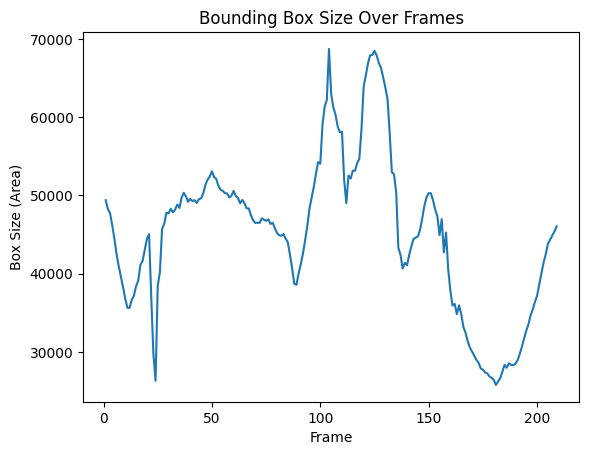

In [11]:
# Extract frames and calculate box sizes (area) from list_of_poses
frames = [pose['frame'] for pose in list_of_poses]
sizes = []

for pose in list_of_poses:
    box = pose['boxes']
    xyxy = box.xyxy[0].tolist()  # Assuming one box per frame
    x1, y1, x2, y2 = xyxy
    size = (x2 - x1) * (y2 - y1)
    sizes.append(size)

# Plot the box sizes over frames
plt.plot(frames, sizes)
plt.xlabel('Frame')
plt.ylabel('Box Size (Area)')
plt.title('Bounding Box Size Over Frames')
plt.show()

What can we derive from the size of the bounding box? Well we could think of the body orientation (facing towards us or perpendicular to us), we could think of the arms beeing streched out or not? Several things could be of interest there.

How about the specific keyjponts?

In the default YOLO26 pose model, there are 17 keypoints, each representing a different part of the human body. Here is the mapping of each index to its respective body joint:

1. Nose
2. Left Eye
3. Right Eye
4. Left Ear
5. Right Ear
6. Left Shoulder
7. Right Shoulder
8. Left Elbow
9. Right Elbow
10. Left Wrist
11. Right Wrist
12. Left Hip
13. Right Hip
14. Left Knee
15. Right Knee
16. Left Ankle
17. Right Ankle

We are most interested in the lower extremities, so let's plot them.

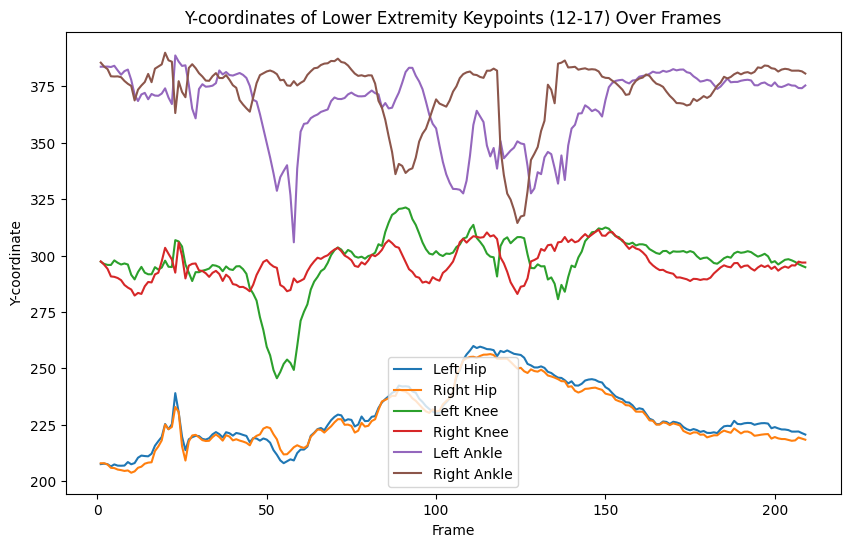

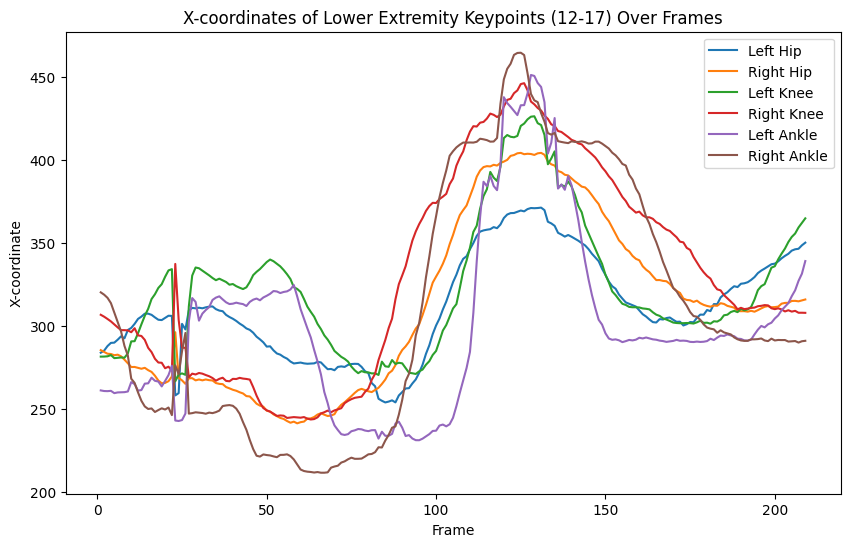

In [14]:
# Extract frames
frames = [pose['frame'] for pose in list_of_poses]

# Keypoints indices 11 to 16 (0-based for keypoints 12-17: Left Hip, Right Hip, Left Knee, Right Knee, Left Ankle, Right Ankle)
keypoint_indices = range(11, 17)
keypoint_names = ['Left Hip', 'Right Hip', 'Left Knee', 'Right Knee', 'Left Ankle', 'Right Ankle']

# Initialize lists for coordinates of each keypoint
y_coords = {i: [] for i in keypoint_indices}
x_coords = {i: [] for i in keypoint_indices}

for pose in list_of_poses:
    keypoints = pose['keypoints']
    xy = keypoints.xy[0]  # Shape: (17, 2) for x, y coordinates
    for idx in keypoint_indices:
        y_coords[idx].append(xy[idx][1].item())
        x_coords[idx].append(xy[idx][0].item())

# Plot the y-coordinates over frames
plt.figure(figsize=(10, 6))
for idx, name in zip(keypoint_indices, keypoint_names):
    plt.plot(frames, y_coords[idx], label=name)

plt.xlabel('Frame')
plt.ylabel('Y-coordinate')
plt.title('Y-coordinates of Lower Extremity Keypoints (12-17) Over Frames')
plt.legend()
plt.show()

# Plot the y-coordinates over frames
plt.figure(figsize=(10, 6))
for idx, name in zip(keypoint_indices, keypoint_names):
    plt.plot(frames, x_coords[idx], label=name)

plt.xlabel('Frame')
plt.ylabel('X-coordinate')
plt.title('X-coordinates of Lower Extremity Keypoints (12-17) Over Frames')
plt.legend()
plt.show()

Well, now we can see that the y-coordinates are given in three main levels. That makes sense, as the ankles are the closest to the floor on average, followed by the knees and hips. Also, based on the joint situation it is clear, that the hips do not have the same range of motion compared to the knees or the ankles. In the x-coordinates, we also see a specific motion. It can be interpreted as a step toward the right side of the image and back. This is supported by the video.

#### TASK:
* Combine Pose estimation and Object Detection and identify variables that could be of interest for the downstream task of touch identification (e.g. what part of the body touched the ball and when).

In [ ]:
# your code here

If you do not know hoe to do it, feel free to run the cells below

# 3. Combine Object Tracking and Pose Esitmation

By applying the lectures from Object Tracking we can use the following code:

In [15]:
# Updated YOLO tracking function with changeable confidence threshold for the ball class
def yolo_Track_Extended(video_path, ball_conf_threshold=0.5):
    # Load YOLO model with tracking enabled
    model = YOLO("yolo26x.pt")
    
    cap = cv.VideoCapture(video_path)
    no_Frames = int(cap.get(cv.CAP_PROP_FRAME_COUNT))
    print('Total number of frames is', no_Frames)
    
    tracked_objects = []  # List to store tracked objects
    frame_count = 0
    
    while True:
        ret, frame = cap.read()
        if not ret:
            print('No frames grabbed!')
            break
        
        frame_count += 1
        
        # Process frame with YOLOv26x tracking, only for classes 0 (person) and 32 (sports ball)
        results = model.track(frame, classes=[0, 32], persist=True)
        
        if results[0].boxes is not None:
            for box in results[0].boxes:
                obj_id = int(box.id.item()) if box.id is not None else None
                bbox = box.xyxy[0].tolist()  # [x1, y1, x2, y2]
                cls = int(box.cls.item())
                conf = box.conf.item()
                
                # Skip balls with confidence below the threshold
                if cls == 32 and conf < ball_conf_threshold:
                    continue
                
                tracked_objects.append({
                    'frame': frame_count,
                    'id': obj_id,
                    'class': cls,
                    'bbox': bbox,
                    'confidence': conf
                })
        
        # Optional: Display the frame (comment out if not needed)
        #frame_ = results[0].plot()
        #cv.imshow('Result YOLO frame', frame_)
        
        k = cv.waitKey(30) & 0xff
        if k == 27:
            break
    
    cap.release()
    cv.destroyAllWindows()
    
    return tracked_objects

# Call the extended function with a higher confidence threshold for balls
object_tracked_data=yolo_Track_Extended(video_path=videopath, ball_conf_threshold=0.005)

Total number of frames is 209

0: 512x640 1 person, 2 sports balls, 278.9ms
Speed: 1.2ms preprocess, 278.9ms inference, 0.2ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 2 sports balls, 243.5ms
Speed: 1.2ms preprocess, 243.5ms inference, 0.2ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 2 sports balls, 287.1ms
Speed: 1.8ms preprocess, 287.1ms inference, 0.2ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 2 sports balls, 284.2ms
Speed: 1.6ms preprocess, 284.2ms inference, 0.2ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 2 sports balls, 304.8ms
Speed: 1.6ms preprocess, 304.8ms inference, 0.2ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 2 sports balls, 260.5ms
Speed: 1.3ms preprocess, 260.5ms inference, 0.2ms postprocess per image at shape (1, 3, 512, 640)

0: 512x640 1 person, 2 sports balls, 264.4ms
Speed: 1.6ms preprocess, 264.4ms inference, 0.2ms postproces

In [16]:
def interpolate_ball_tracking(tracked_data, ball_id=6, ball_class=32):
    # Filter data for the specific ball (class 32, id 6)
    ball_data = [d for d in tracked_data if d['class'] == ball_class and d.get('id') == ball_id]
    
    if not ball_data:
        return tracked_data  # No data to interpolate
    
    # Sort by frame
    ball_data.sort(key=lambda x: x['frame'])
    
    # Find gaps
    interpolated_data = []
    for i in range(len(ball_data) - 1):
        current = ball_data[i]
        next_ = ball_data[i + 1]
        gap_frames = next_['frame'] - current['frame'] - 1
        
        if gap_frames > 0:
            # Interpolate bbox linearly
            start_bbox = current['bbox']
            end_bbox = next_['bbox']
            for j in range(1, gap_frames + 1):
                t = j / (gap_frames + 1)
                interp_bbox = [
                    start_bbox[0] + t * (end_bbox[0] - start_bbox[0]),
                    start_bbox[1] + t * (end_bbox[1] - start_bbox[1]),
                    start_bbox[2] + t * (end_bbox[2] - start_bbox[2]),
                    start_bbox[3] + t * (end_bbox[3] - start_bbox[3])
                ]
                interpolated_data.append({
                    'frame': current['frame'] + j,
                    'id': ball_id,
                    'class': ball_class,
                    'bbox': interp_bbox,
                    'confidence': (current['confidence'] + next_['confidence']) / 2  # Average confidence
                })
    
    # Add interpolated data to tracked_data
    tracked_data.extend(interpolated_data)
    # Sort the entire list by frame
    tracked_data.sort(key=lambda x: x['frame'])
    
    return tracked_data

# Call the function to interpolate missing ball tracking
object_tracked_data_interpolated = interpolate_ball_tracking(object_tracked_data, ball_id=6, ball_class=32)

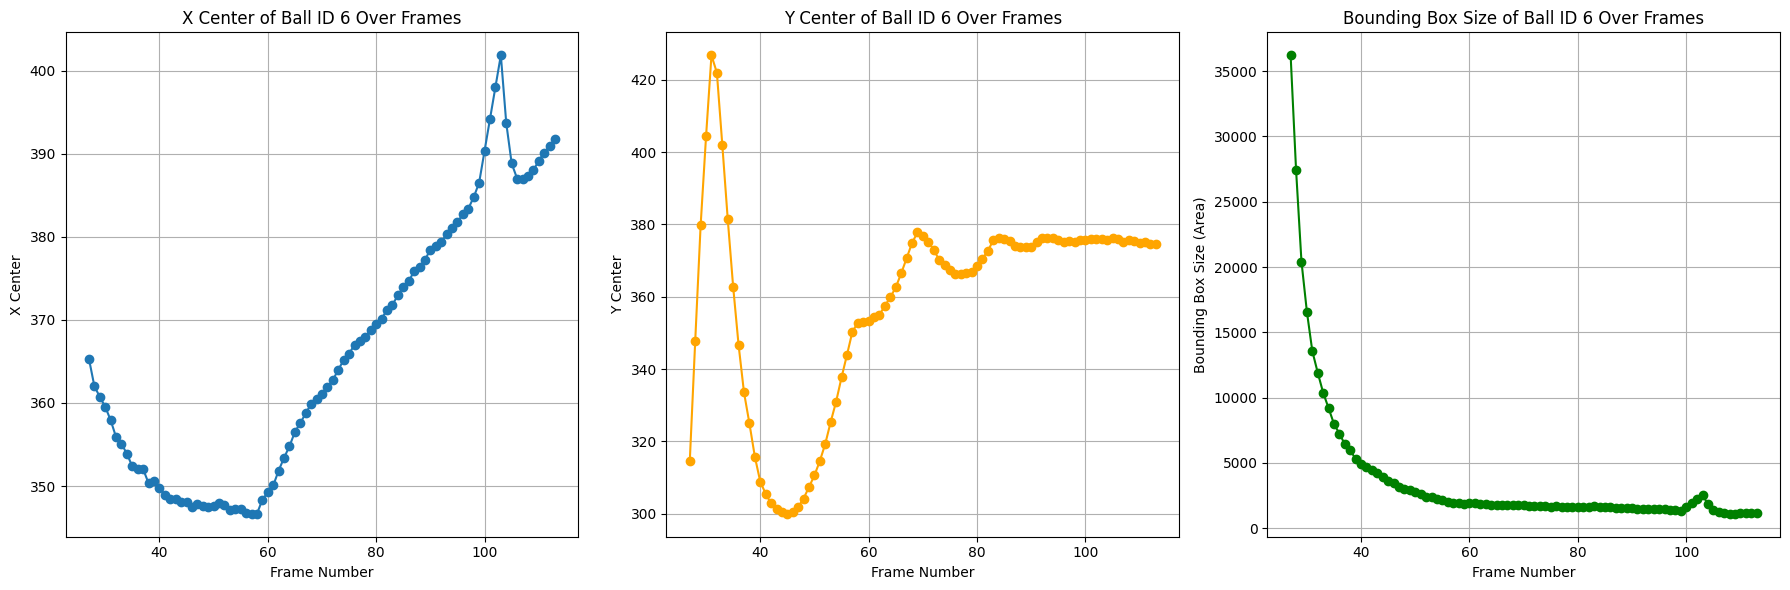

In [21]:
def plot_ball_trajectory(tracked_data, ball_id=6):
    # Filter data for sports balls with the specified ID
    balls_id = [d for d in tracked_data if d['class'] == 32 and d.get('id') == ball_id]
    
    # Extract frames, x_centers, y_centers, and sizes
    frames = [ball['frame'] for ball in balls_id]
    x_centers = [(ball['bbox'][0] + ball['bbox'][2]) / 2 for ball in balls_id]
    y_centers = [(ball['bbox'][1] + ball['bbox'][3]) / 2 for ball in balls_id]
    sizes = [(ball['bbox'][2] - ball['bbox'][0]) * (ball['bbox'][3] - ball['bbox'][1]) for ball in balls_id]
    
    # Plot x and y centers and size over frames
    plt.figure(figsize=(18, 6))
    
    plt.subplot(1, 3, 1)
    plt.plot(frames, x_centers, marker='o')
    plt.xlabel('Frame Number')
    plt.ylabel('X Center')
    plt.title(f'X Center of Ball ID {ball_id} Over Frames')
    plt.grid(True)
    
    plt.subplot(1, 3, 2)
    plt.plot(frames, y_centers, marker='o', color='orange')
    plt.xlabel('Frame Number')
    plt.ylabel('Y Center')
    plt.title(f'Y Center of Ball ID {ball_id} Over Frames')
    plt.grid(True)
    
    plt.subplot(1, 3, 3)
    plt.plot(frames, sizes, marker='o', color='green')
    plt.xlabel('Frame Number')
    plt.ylabel('Bounding Box Size (Area)')
    plt.title(f'Bounding Box Size of Ball ID {ball_id} Over Frames')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()


# Call the function with the existing tracked_data
plot_ball_trajectory(object_tracked_data_interpolated)


What we can see, is that the bounding box of the ball is also changing over time (which is something to expect, as the object is moving away from the camera till the ball is touched by the athlete). 

# 4. Strategies to do further Analysis and Processing

#### TASK:
* Discuss what the next step might be
* What are the relevant inputs for a potential downstream task of performance analysis?
* Are there any steps necessary (e.g. calculate the posture angles, velocities, etc.)?
* Transfer the learnings to a rehabilitation task (e.g. stroke patient is learning to graps again)